In [8]:
# %pip install pandas -q

In [11]:

print(1)

1


In [6]:
import pandas as pd



In [ ]:
# df = pd.read_json("candidates.jsonl", lines=True)
# df

In [ ]:
# df.to_csv('dataset.csv', index=True)


In [8]:
df=pd.read_csv("dataset.csv")
df.head()

,Unnamed: 0,candidate_id,profile,career_history,education,skills,certifications,languages,redrob_signals
0,0,CAND_0000001,"{'anonymized_name': 'Ira Vora', 'headline': 'B...","[{'company': 'Mindtree', 'title': 'Backend Eng...",[{'institution': 'Lovely Professional Universi...,"[{'name': 'Tailwind', 'proficiency': 'intermed...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 86.9, 'signup_d..."
1,1,CAND_0000002,"{'anonymized_name': 'Saanvi Sethi', 'headline'...","[{'company': 'Wipro', 'title': 'Operations Man...","[{'institution': 'Local Engineering College', ...","[{'name': 'Project Management', 'proficiency':...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 78.7, 'signup_d..."
2,2,CAND_0000003,"{'anonymized_name': 'Yash Agarwal', 'headline'...","[{'company': 'TCS', 'title': 'Customer Support...","[{'institution': 'Local Engineering College', ...","[{'name': 'Angular', 'proficiency': 'intermedi...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 31.9, 'signup_d..."
3,3,CAND_0000004,"{'anonymized_name': 'Anil Bose', 'headline': '...","[{'company': 'Dunder Mifflin', 'title': 'Marke...","[{'institution': 'Local Engineering College', ...","[{'name': 'Node.js', 'proficiency': 'intermedi...","[{'name': 'AWS Certified Cloud Practitioner', ...","[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 28.5, 'signup_d..."
4,4,CAND_0000005,"{'anonymized_name': 'Aisha Sethi', 'headline':...","[{'company': 'Stark Industries', 'title': 'Acc...","[{'institution': 'Chandigarh University', 'deg...","[{'name': 'SQL', 'proficiency': 'beginner', 'e...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 84.6, 'signup_d..."


In [17]:
pd.set_option('display.expand_frame_repr', False)
print(df.head())


   Unnamed: 0  candidate_id                                            profile                                     career_history                                          education                                             skills                                     certifications                                          languages                                     redrob_signals
0           0  CAND_0000001  {'anonymized_name': 'Ira Vora', 'headline': 'B...  [{'company': 'Mindtree', 'title': 'Backend Eng...  [{'institution': 'Lovely Professional Universi...  [{'name': 'Tailwind', 'proficiency': 'intermed...                                                 []  [{'language': 'English', 'proficiency': 'profe...  {'profile_completeness_score': 86.9, 'signup_d...
1           1  CAND_0000002  {'anonymized_name': 'Saanvi Sethi', 'headline'...  [{'company': 'Wipro', 'title': 'Operations Man...  [{'institution': 'Local Engineering College', ...  [{'name': 'Project Management', 'proficiency':..

In [10]:
%pip install matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Top Skills by Frequency:
                               S.No.  count
HTML                               1  12246
Databricks                         2  12244
Redux                              3  12222
Terraform                          4  12187
Angular                            5  12173
Salesforce CRM                     6  12157
Figma                              7  12157
Vue.js                             8  12142
Sales                              9  12138
Accounting                        10  12136
Agile                             11  12135
Kafka                             12  12114
Excel                             13  12109
BigQuery                          14  12108
CI/CD                             15  12108
Project Management                16  12106
Airflow                           17  12105
Flask                             18  12104
AWS                               19  12104
Scrum                             20  12083
Illustrator                       21  12072
Kuberne

<Figure size 1200x800 with 0 Axes>

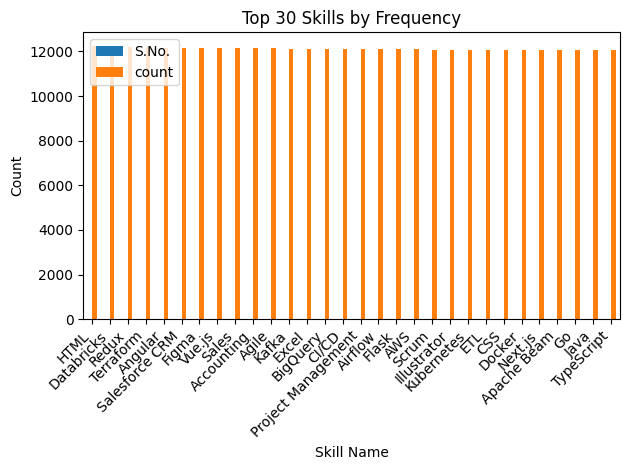

In [7]:
pd.set_option('display.max_rows', None)

import json
from collections import Counter
import matplotlib.pyplot as plt
# import pandas as pd

# Read the JSONL file and extract skills
skill_counter = Counter()

with open('candidates.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        candidate = json.loads(line)
        if 'skills' in candidate:
            for skill in candidate['skills']:
                skill_name = skill.get('name', '').strip()
                if skill_name:
                    skill_counter[skill_name] += 1

# Convert to DataFrame and sort by count (descending)
skills_df = pd.DataFrame.from_dict(skill_counter, orient='index', columns=['count'])
skills_df = skills_df.sort_values('count', ascending=False)

# Display top 50 skills
print("Top Skills by Frequency:")
# Assign serial numbers
skills_df.insert(0, 'S.No.', range(1, len(skills_df) + 1))
print(skills_df)



# Create visualization
plt.figure(figsize=(12, 8))
skills_df.head(30).plot(kind='bar')
plt.title('Top 30 Skills by Frequency')
plt.xlabel('Skill Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [3]:
# Number of unique skills
print(f"Number of unique skills: {len(skill_counter)}")

Number of unique skills: 133


In [18]:
# Check the structure of the skills column
print("Type of skills column:", type(df["skills"].iloc[0]))
print("First few skills entries:")
for i in range(min(3, len(df))):
    print(f"Candidate {i}:")
    print(f"  Type: {type(df['skills'].iloc[i])}")
    print(f"  Content: {df['skills'].iloc[i]}")
    print()

# Check if skills are stored as JSON strings
if isinstance(df["skills"].iloc[0], str):
    print("Skills are stored as strings - need to parse JSON")
    import json
    df["skills"] = df["skills"].apply(json.loads)

Type of skills column: <class 'str'>
First few skills entries:
Candidate 0:
  Type: <class 'str'>
  Content: [{'name': 'Tailwind', 'proficiency': 'intermediate', 'endorsements': 3, 'duration_months': 13}, {'name': 'NLP', 'proficiency': 'advanced', 'endorsements': 37, 'duration_months': 26}, {'name': 'Image Classification', 'proficiency': 'advanced', 'endorsements': 7, 'duration_months': 40}, {'name': 'Fine-tuning LLMs', 'proficiency': 'advanced', 'endorsements': 21, 'duration_months': 36}, {'name': 'Weights & Biases', 'proficiency': 'intermediate', 'endorsements': 13, 'duration_months': 30}, {'name': 'Speech Recognition', 'proficiency': 'advanced', 'endorsements': 52, 'duration_months': 33}, {'name': 'Photoshop', 'proficiency': 'intermediate', 'endorsements': 8, 'duration_months': 24}, {'name': 'TTS', 'proficiency': 'advanced', 'endorsements': 56, 'duration_months': 60}, {'name': 'LoRA', 'proficiency': 'intermediate', 'endorsements': 0, 'duration_months': 28}, {'name': 'Apache Beam', '

JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 3 (char 2)

In [23]:
import json

def safe_parse_skills(skills_str):
    # Handle None, NaN, empty strings, and already-parsed lists
    if skills_str is None or (isinstance(skills_str, str) and skills_str.strip() == ''):
        return []
    # If it's already a list, return it as-is
    if isinstance(skills_str, list):
        return skills_str
    try:
        return json.loads(skills_str)
    except (json.JSONDecodeError, TypeError, ValueError):
        return []

# Parse JSON strings to Python lists safely
df["skills"] = df["skills"].apply(safe_parse_skills)

# Now run your filtering code
filtered_df = df[df["skills"].apply(has_relevant_skill)].copy()

print("Original candidates:", len(df))
print("Filtered candidates:", len(filtered_df))
print("Candidates removed:", len(df) - len(filtered_df))

Original candidates: 100000
Filtered candidates: 0
Candidates removed: 100000


In [24]:
# List of skills to retain
relevant_skills = {
    "Databricks", "Terraform", "Kafka", "BigQuery", "CI/CD", "Airflow",
    "Flask", "AWS", "Kubernetes", "ETL", "Docker", "Apache Beam",
    "Go", "Java", "TypeScript", "JavaScript", "dbt", "REST APIs",
    "Spark", "Snowflake", "GCP", "PostgreSQL", "Rust", "Apache Flink",
    "gRPC", "SQL", "Hadoop", "Redis", "FastAPI", "Microservices",
    "Data Pipelines", "Azure",

    "Hugging Face Transformers", "LangChain", "Information Retrieval",
    "LLMs", "Recommendation Systems", "Semantic Search",
    "Sentence Transformers", "Embeddings", "Vector Search",
    "Pinecone", "Prompt Engineering", "FAISS", "RAG",
    "Fine-tuning LLMs", "YOLO", "GANs", "Feature Engineering",
    "OpenCV", "ASR", "Image Classification", "Computer Vision",
    "Speech Recognition", "CNN", "Kubeflow", "MLOps",
    "BentoML", "Reinforcement Learning", "Data Science",
    "Object Detection", "Diffusion Models", "MLflow",
    "Time Series", "Weights & Biases", "Forecasting",
    "TTS", "Statistical Modeling", "QLoRA", "pgvector",
    "Weaviate", "Milvus", "Learning to Rank", "BM25",
    "TensorFlow", "Qdrant", "Python", "PyTorch",
    "PEFT", "LoRA", "NLP", "Machine Learning",
    "Deep Learning", "Haystack", "Elasticsearch",
    "LlamaIndex", "scikit-learn", "OpenSearch",
    "Information Retrieval Systems", "Text Encoders",
    "Search Backend", "Model Adaptation",
    "Search & Discovery", "Ranking Systems",
    "Vector Representations", "Content Matching",
    "Workflow Orchestration", "Search Infrastructure",
    "Indexing Algorithms", "Open-source ML libraries",
    "Natural Language Processing", "Document Processing"
}

relevant_skills = {skill.lower() for skill in relevant_skills}

# Function to check if candidate has at least one relevant skill
def has_relevant_skill(skills):
    if not isinstance(skills, list):
        return False

    return any(
        skill.get("name", "").strip().lower() in relevant_skills
        for skill in skills
        if isinstance(skill, dict)
    )

# Filter candidates
filtered_df = df[df["skills"].apply(has_relevant_skill)].copy()

print("Original candidates:", len(df))
print("Filtered candidates:", len(filtered_df))
print("Candidates removed:", len(df) - len(filtered_df))

Original candidates: 100000
Filtered candidates: 0
Candidates removed: 100000


In [26]:
# Check what the skills column looks like after parsing
print("Type of skills column after parsing:", type(df["skills"].iloc[0]))
print("First 3 entries after parsing:")
for i in range(min(3, len(df))):
    print(f"Candidate {i}: {df['skills'].iloc[i]}")
    print()

# Also check the original raw data before any parsing
# Let's reload a small sample to see the original structure
import json
with open('candidates.jsonl', 'r') as f:
    first_line = f.readline()
    first_candidate = json.loads(first_line)
    print("Original skills from JSONL file:")
    print(first_candidate['skills'][:3])  # First 3 skills

Type of skills column after parsing: <class 'list'>
First 3 entries after parsing:
Candidate 0: []

Candidate 1: []

Candidate 2: []

Original skills from JSONL file:
[{'name': 'Tailwind', 'proficiency': 'intermediate', 'endorsements': 3, 'duration_months': 13}, {'name': 'NLP', 'proficiency': 'advanced', 'endorsements': 37, 'duration_months': 26}, {'name': 'Image Classification', 'proficiency': 'advanced', 'endorsements': 7, 'duration_months': 40}]


In [16]:
for skill in df.iloc[0]["skills"][:5]:
    print(skill)

[
{
'
n
a


In [ ]:
def matched_skills(skills):
    if not isinstance(skills, list):
        return []

    return [
        skill.get("name")
        for skill in skills
        if isinstance(skill, dict)
        and skill.get("name", "").strip().lower() in relevant_skills
    ]

filtered_df["matched_skills"] = filtered_df["skills"].apply(matched_skills)